Generated fex_efficiency_chart.svg and .png


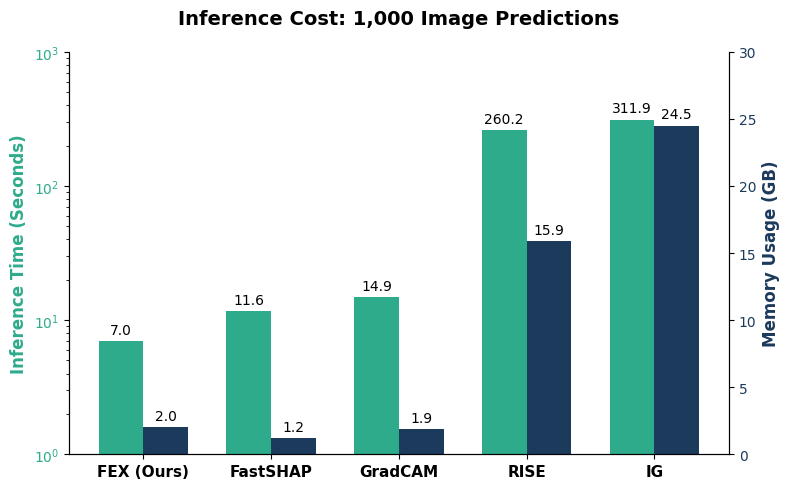

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data from FEX paper Table 3 (1000 image predictions)
methods = ['FEX (Ours)', 'FastSHAP', 'GradCAM', 'RISE', 'IG']
time_sec = [7.0, 11.6, 14.9, 260.2, 311.9]
memory_gb = [2.0, 1.2, 1.9, 15.9, 24.5]

# Colors matching the established palette
color_teal = '#2EAB8B'
color_navy = '#1B3A5C'

x = np.arange(len(methods))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Time (Left Y-axis)
rects1 = ax1.bar(x - width/2, time_sec, width, label='Time (s)', color=color_teal)
ax1.set_ylabel('Inference Time (Seconds)', color=color_teal, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_teal)
ax1.set_yscale('log') # Log scale emphasizes the massive gap
ax1.set_ylim(1, 1000)

# Plot Memory (Right Y-axis)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, memory_gb, width, label='Memory (GB)', color=color_navy)
ax2.set_ylabel('Memory Usage (GB)', color=color_navy, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_navy)
ax2.set_ylim(0, 30)

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Add values on top of bars
def autolabel(rects, ax, y_offset=3):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, y_offset),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1, ax1)
autolabel(rects2, ax2)

plt.title('Inference Cost: 1,000 Image Predictions', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

# Save as SVG and PNG
plt.savefig('fex_efficiency_chart.svg', format='svg', transparent=True)
plt.savefig('fex_efficiency_chart.png', format='png', dpi=300, transparent=True)
print("Generated fex_efficiency_chart.svg and .png")